## Calculate 20-year temperature, salinity, and oxygen climatologies using Roemmich & Gilson Argo Data Product and GOBAI-O2-v2.3

In [1]:
import s3fs
import xarray as xr
import boto3
import gsw
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib
import matplotlib.patches as mpatches
import cmocean

##### Start AWS session

In [ ]:
boto_session = boto3.Session()
s3_creds = boto_session.get_credentials()
s3_creds2 = s3_creds.get_frozen_credentials()

print(s3_creds2)

In [3]:
boto_session

Session(region_name='us-west-2')

In [2]:
fs = s3fs.S3FileSystem(anon=False)

s3_path = "s3://uw-escience-scratch-prod/team_mhw/GOBAI-O2-v2.3.nc"
#open GOBAI
ds_GOBAI = xr.open_dataset(s3_path, engine="h5netcdf")

In [ ]:
# aws s3 cp /Users/steviewalker/Documents/GO-BGC_MHW/GOBAI-O2-v2.3.nc s3://uw-escience-scratch-prod/team_mhw/GOBAI-O2-v2.3.nc

In [4]:
#convert longitude to 0 - 360
def lon_convert(data):
    data.coords['lon'] = (((360 + (data.lon % 360)) % 360))
    data_new_lon = data.sortby(data.lon)
    return data_new_lon

In [5]:
ds_GOBAI = lon_convert(ds_GOBAI)

### Monthly climatological averages

In [ ]:
#save path
save_path = "s3://uw-escience-scratch-prod/team_mhw/"

# Read in coordinates
time = ds_GOBAI['time']
pres = ds_GOBAI['pres']
lon = ds_GOBAI['lon']
lat = ds_GOBAI['lat']

# read in temp, sal, oxy, for one lat ----------
vars_to_read = ['temp', 'sal']
start_data = {var: ds_GOBAI[var] for var in vars_to_read}

# convert practical salinity to absolute salinity, in situ temp to conservative temp
def convert_sal_temp(sal, temp):
    SA = gsw.SA_from_SP(SP=sal, p=pres, lon=lon, lat=lat)
    PT = gsw.pt_from_t(SA=SA, t=temp, p=pres, p_ref=0)
    return SA, PT
SA, PT = convert_sal_temp(start_data['sal'], start_data['temp'])

SA_avg = SA.groupby('time.month').mean(dim='time')

#save SA
da_SA = xr.DataArray(SA_avg,dims=['month','pres','lat','lon'], coords=dict(lon=lon, lat=lat, pres=pres, month=SA_avg['month'].values),name='sal').assign_attrs(long_name="Absolute Salinity", units="unitless",
                     description="monthly climatological averages (2004-2024), calculated with GSW",source="RG09 Argo Climatology, Roemmich & Gilson, 2009")
da_SA.to_netcdf(path='/tmp/RG09_absolute_salinity_2004-2024_monthly_climatology.nc', mode = 'w')
del SA, SA_avg, da_SA

PT_avg = PT.groupby('time.month').mean(dim='time')

#save CT
da_PT = xr.DataArray(PT_avg,dims=['month','pres','lat','lon'], coords=dict(lon=lon, lat=lat, pres=pres, month=PT_avg['month'].values),name = 'temp').assign_attrs(long_name = "Potential Temperature", units = "celcius", description = "climatological average (2004-2024),calculated with GSW",
                     source = "RG09 Argo Climatology, Roemmich & Gilson, 2009")
da_PT.to_netcdf(path='/tmp/RG09_potential_temperature_2004-2024_monthly_climatology.nc', mode = 'w')
del PT, PT_avg, da_PT

oxy_avg = ds_GOBAI['oxy'].groupby('time.month').mean(dim='time')

#save oxy
da_oxy = xr.DataArray(oxy_avg,dims=['month','pres','lat','lon'], coords=dict(lon=lon, lat=lat, pres=pres, month=oxy_avg['month'].values),name = 'oxy').assign_attrs(long_name = "Dissolved Oxygen", units = "umol/kg", description = "climatological average (2004-2024)",
                     source = "GOBAI-O2-v2.3, Sharp et al. 2023")
da_oxy.to_netcdf(path='/tmp/GOBAI-O2-v2.3_oxygen_2004-2024_monthly_climatology.nc', mode = 'w')
del oxy_avg, da_oxy


### In terminal, run these lines to upload from tmp to AWS bucket:

aws s3 cp /tmp/GOBAI-O2-v2.3_oxygen_2004-2024_monthly_climatology.nc s3://uw-escience-scratch-prod/team_mhw/


aws s3 cp /tmp/RG09_potential_temperature_2004-2024_monthly_climatology.nc s3://uw-escience-scratch-prod/team_mhw/


aws s3 cp /tmp/RG09_absolute_salinity_2004-2024_monthly_climatology.nc s3://uw-escience-scratch-prod/team_mhw/

### Climatological average 2004-2024

In [6]:
#save path
save_path = "s3://uw-escience-scratch-prod/team_mhw/"

# Read in coordinates
time = ds_GOBAI['time']
pres = ds_GOBAI['pres']
lon = ds_GOBAI['lon']
lat = ds_GOBAI['lat']

# read in temp, sal, oxy, for one lat ----------
vars_to_read = ['temp', 'sal']
start_data = {var: ds_GOBAI[var] for var in vars_to_read}

# convert practical salinity to absolute salinity, in situ temp to conservative temp
def convert_sal_temp(sal, temp):
    SA = gsw.SA_from_SP(SP=sal, p=pres, lon=lon, lat=lat)
    PT = gsw.pt_from_t(SA=SA, t=temp, p=pres, p_ref=0)
    return SA, PT
SA, PT = convert_sal_temp(start_data['sal'], start_data['temp'])

SA_avg = SA.mean(dim = 'time')

#save SA
da_SA = xr.DataArray(SA_avg,dims = ['pres','lat','lon'], coords=dict(lon=lon,lat=lat,pres=pres) ,name = 'sal').assign_attrs(long_name = "Absolute Salinity", units = "unitless", description = "climatological average (2004-2024),calculated with GSW",
                     source = "RG09 Argo Climatology, Roemmich & Gilson, 2009")
da_SA.to_netcdf(path='/tmp/RG09_absolute_salinity_2004-2024_climatology.nc', mode = 'w')
del SA, SA_avg, da_SA

PT_avg = PT.mean(dim = 'time')

#save CT
da_PT = xr.DataArray(PT_avg,dims = ['pres','lat','lon'], coords=dict(lon=lon,lat=lat,pres=pres) ,name = 'temp').assign_attrs(long_name = "Potential Temperature", units = "celcius", description = "climatological average (2004-2024),calculated with GSW",
                     source = "RG09 Argo Climatology, Roemmich & Gilson, 2009")
da_PT.to_netcdf(path='/tmp/RG09_potential_temperature_2004-2024_climatology.nc', mode = 'w')
del PT, PT_avg, da_PT

oxy_avg = ds_GOBAI['oxy'].mean(dim = 'time')

#save oxy
da_oxy = xr.DataArray(oxy_avg,dims = ['pres','lat','lon'], coords=dict(lon=lon,lat=lat,pres=pres) ,name = 'oxy').assign_attrs(long_name = "Dissolved Oxygen", units = "umol/kg", description = "climatological average (2004-2024)",
                     source = "GOBAI-O2-v2.3, Sharp et al. 2023")
da_oxy.to_netcdf(path='/tmp/GOBAI-O2-v2.3_oxygen_2004-2024_climatology.nc', mode = 'w')
del oxy_avg, da_oxy


### In terminal, run these lines to upload from tmp to AWS bucket:

aws s3 cp /tmp/GOBAI-O2-v2.3_oxygen_2004-2024_climatology.nc s3://uw-escience-scratch-prod/team_mhw/


aws s3 cp /tmp/RG09_potential_temperature_2004-2024_climatology.nc s3://uw-escience-scratch-prod/team_mhw/


aws s3 cp /tmp/RG09_absolute_salinity_2004-2024_climatology.nc s3://uw-escience-scratch-prod/team_mhw/

## Plots for SW Pac and N Atl MHW regions

In [2]:
s3_path = "s3://uw-escience-scratch-prod/team_mhw/"
#open GOBAI
ds = xr.open_dataset(s3_path+'RG09_potential_temperature_2004-2024_monthly_climatology.nc', engine="h5netcdf")


In [8]:
# SW Pac
# lon0 = 220
# lon1 = 330
# lat0 = -60
# lat1 = -40

# N Atl
lon0 = 300
lon1 = 360
lat0 = 10
lat1 = 50


Text(0.5, 1.0, 'SST in N Atlantic')

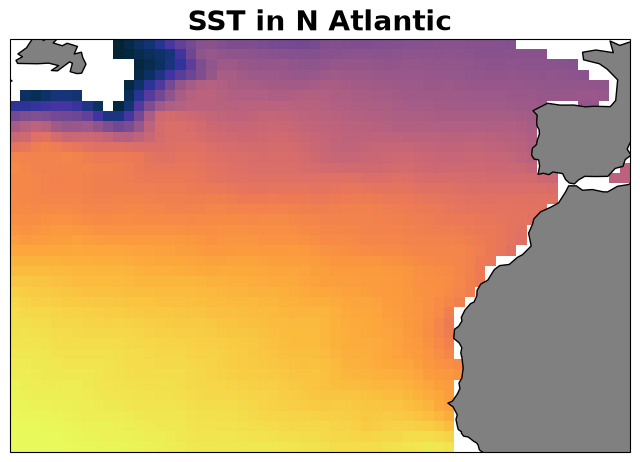

In [10]:
SWPac = ds['temp'].sel(lat=slice(lat0,lat1),lon=slice(lon0,lon1),month=1,pres=2.5)
data = SWPac
title_size = 20
axis_size = 17
tick_size = 13
colorbar_label = "SST (deg C)"
title = "SST in N Atlantic"
#assign projection type
crs0 = ccrs.PlateCarree()

#create figure object
fig = plt.figure(figsize = (8,8))

#add panel
ax = fig.add_subplot(111, projection = crs0)
coast_50m = cfeature.NaturalEarthFeature('physical', 'land', '110m', edgecolor='k', facecolor='gray')
ax.add_feature(coast_50m)
ax.set_facecolor('white')

#Colormap specification
color = cmocean.cm.thermal
# plot satellite data
plot = data.plot(cmap=color,transform=crs0,add_colorbar=False) 

cbar = fig.colorbar(plot,fraction=0.018, pad=0.02)
cbar.ax.tick_params(labelsize=tick_size)
cbar.set_label(colorbar_label, size = axis_size)        

# # Gridlines
# gl = ax.gridlines(crs=crs0, draw_labels=True, x_inline=False, y_inline=False,
#       linewidth=1, color='gray', alpha=0.3, linestyle='-')
# gl.xlabel_style = {'size': tick_size, 'color': 'k'}
# gl.ylabel_style = {'size': tick_size, 'color': 'k'}
# gl.top_labels = False

# # Rectangle showing MHW region
# rect = mpatches.Rectangle((lon0, lat0),
#                           lon1 - lon0,
#                           lat1 - lat0,
#                           transform=ccrs.PlateCarree(),
#                           facecolor='none', edgecolor='red',
#                           linewidth=1.5, linestyle='--')
# ax.add_patch(rect)

ax.set_title(title, size=title_size, weight='bold')
#chla colorbar
# cbar = fig.colorbar(plot, fraction=0.02, pad=0.03)
# cbar.set_label('SST in January')
# cbar.update_ticks()

